# FatigueSet Final Dataset — Exploratory Data Analysis

This notebook performs EDA on `datastore/fatigueset_final.csv`, including:
- Timestamp normalization sanity check (no negative `window_start_sec`)
- Subject × session completeness check (are all 36 combinations present?)
- Windowing coverage check (block-restricted windowing vs. full session)
- Label distribution and coverage analysis (physical fatigue score, block-level matching)
- Feature statistics and range validation (HR 25–240 bpm per spec)
- LF/HF confidence analysis (2-minute window, `lf_hf_low_confidence` flag)
- Missing data report (per column, per subject)
- Feature correlations and balance checks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
np.random.seed(42)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Load Dataset

In [2]:
df = pd.read_csv('../datastore/fatigueset_final.csv')

print(f"✓ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  File: datastore/fatigueset_final.csv")
print(f"  Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n  Date range (window_start_sec): {df['window_start_sec'].min():.1f}–{df['window_start_sec'].max():.1f} seconds")

✓ Dataset loaded: 652 rows × 17 columns
  File: datastore/fatigueset_final.csv
  Memory usage: 0.26 MB

  Date range (window_start_sec): 0.0–1535.0 seconds


## 1b. Sanity Check — Timestamp Normalization

In [3]:
# Confirm the negative window_start_sec clamp fix is actually in effect
neg_count = (df['window_start_sec'] < 0).sum()
min_ws = df['window_start_sec'].min()

print(f"Minimum window_start_sec: {min_ws}")
print(f"Rows with negative window_start_sec: {neg_count}")
print(f"{'✓ PASS' if neg_count == 0 else '⚠ FAIL'} — clamp-to-zero fix "
      f"{'is' if neg_count == 0 else 'is NOT'} in effect on this file.")


Minimum window_start_sec: 0.0
Rows with negative window_start_sec: 0
✓ PASS — clamp-to-zero fix is in effect on this file.


## 2. Data Inspection

In [4]:
print("Column Info:")
print(df.info())
print("\n" + "="*60)
print("First 5 rows:")
print(df.head())
print("\n" + "="*60)
print("Data types:")
print(df.dtypes)
print("\n" + "="*60)
print("Unique values per column:")
print(df.nunique())

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            652 non-null    object 
 1   session_id            652 non-null    int64  
 2   window_start_sec      652 non-null    float64
 3   hr                    652 non-null    float64
 4   rmssd                 652 non-null    float64
 5   sdnn                  652 non-null    float64
 6   lf_hf                 496 non-null    float64
 7   lf_hf_window_sec      496 non-null    float64
 8   lf_hf_low_confidence  652 non-null    bool   
 9   data_quality          652 non-null    object 
 10  label                 652 non-null    float64
 11  label_type            652 non-null    object 
 12  sss_pretask           652 non-null    int64  
 13  gvas_sleepy           652 non-null    int64  
 14  intensity_level       652 non-null    object 
 15  modality  

## 3. Missing Data Analysis

Missing Data Per Column:
              Column  Missing_Count  Missing_Pct
    lf_hf_window_sec            156        23.93
               lf_hf            156        23.93
          subject_id              0         0.00
          session_id              0         0.00
    window_start_sec              0         0.00
               rmssd              0         0.00
                  hr              0         0.00
                sdnn              0         0.00
lf_hf_low_confidence              0         0.00
        data_quality              0         0.00
               label              0         0.00
          label_type              0         0.00
         sss_pretask              0         0.00
         gvas_sleepy              0         0.00
     intensity_level              0         0.00
            modality              0         0.00
             dataset              0         0.00

Missing Labels Per Subject:
            Missing_Labels  Total_Rows  Missing_Pct
subject_id  

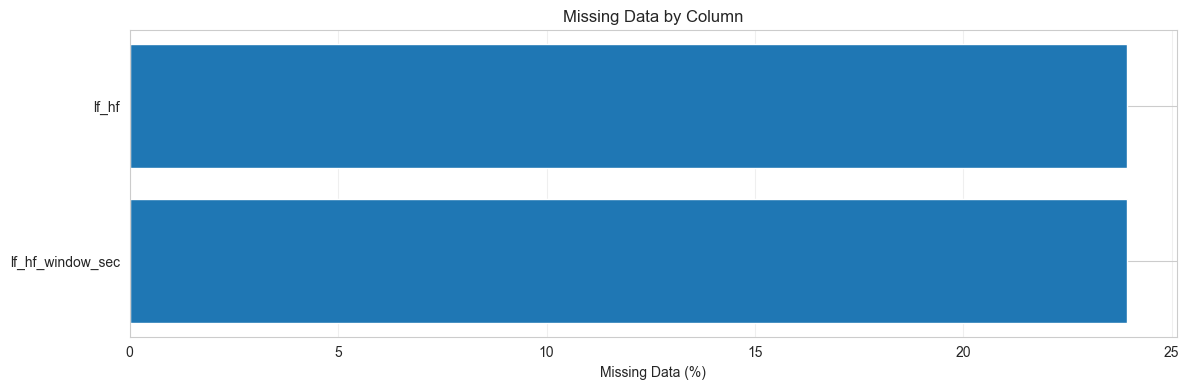


✓  Label missing: 0 / 652 (0.0%)
   Method: Block-level matching — fatigue surveys paired with preceding task blocks
   Recommendation: Full supervised learning is now viable


In [5]:
# Missing data per column
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isna().sum(),
    'Missing_Pct': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('Missing_Pct', ascending=False)

print("Missing Data Per Column:")
print(missing_data.to_string(index=False))

# Missing data per subject
print("\n" + "="*60)
print("Missing Labels Per Subject:")
missing_per_subject = df.groupby('subject_id').agg(
    Missing_Labels=('label', lambda x: x.isna().sum()),
    Total_Rows=('label', 'count')
)
missing_per_subject['Missing_Pct'] = (missing_per_subject['Missing_Labels'] / missing_per_subject['Total_Rows'] * 100).round(1)
print(missing_per_subject)

# Visualize missingness
fig, ax = plt.subplots(figsize=(12, 4))
missing_data_sorted = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Pct')
ax.barh(missing_data_sorted['Column'], missing_data_sorted['Missing_Pct'])
ax.set_xlabel('Missing Data (%)')
ax.set_title('Missing Data by Column')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n{'⚠' if df['label'].isna().sum() > 0 else '✓'}  Label missing: {df['label'].isna().sum()} / {len(df)} ({df['label'].isna().sum()/len(df)*100:.1f}%)")
print("   Method: Block-level matching — fatigue surveys paired with preceding task blocks")
print("   Recommendation: Full supervised learning is now viable")

## 3b. Subject × Session Completeness

In [6]:
# 12 subjects x 3 sessions = 36 expected combinations. Flag any that are
# missing entirely, rather than assuming full coverage.
expected_subjects = [f"P{i:02d}" for i in range(1, 13)]
expected_sessions = [1, 2, 3]

pivot_counts = df.groupby(['subject_id', 'session_id']).size().unstack(fill_value=0)
pivot_counts = pivot_counts.reindex(index=expected_subjects, columns=expected_sessions, fill_value=0)

print("Rows per subject x session (0 = missing entirely):")
print(pivot_counts)

missing_combos = [
    (s, sess) for s in expected_subjects for sess in expected_sessions
    if pivot_counts.loc[s, sess] == 0
]
print(f"\n{'✓ All 36 subject x session combinations present' if not missing_combos else '⚠ MISSING COMBINATIONS:'}")
for combo in missing_combos:
    print(f"  - subject={combo[0]}, session={combo[1]} — zero rows, investigate raw files")


Rows per subject x session (0 = missing entirely):
session_id   1   2   3
subject_id            
P01          0  22  23
P02         20  18  16
P03         19  17  17
P04         21  19  17
P05         19  17  18
P06         22  18  18
P07         18  20  19
P08         17  16  15
P09         22  16  19
P10         19  17  17
P11         22  22  20
P12         19  17  16

⚠ MISSING COMBINATIONS:
  - subject=P01, session=1 — zero rows, investigate raw files


The P01/session_1 data is missing because the ecg.csv has no variation in the time markers

## 3c. Windowing Coverage Check — Block-Restricted vs. Full Session

Current windowing only slices 30s windows **inside the three named task blocks**
(baseline / activity / fatigue) — it does not window the crt/nback filler periods,
the time before baseline starts, or the tail after the fatigue block ends, even
though the raw ECG/RR sensor recorded continuously the whole time. This check
quantifies how much of each session is actually being used.


In [7]:
rows_per_session = df.groupby(['subject_id', 'session_id']).size()

print("Windows (30s each) per subject/session:")
print(rows_per_session.describe())
print()
print(f"Mean windows/session: {rows_per_session.mean():.1f}")
print(f"Min / Max windows/session: {rows_per_session.min()} / {rows_per_session.max()}")
print()
print("For reference, a typical FatigueSet session runs ~1300-1600s, which at a full")
print("30s continuous windowing (no block restriction) would yield ~45-50 windows.")
print(f"Current mean of {rows_per_session.mean():.1f} windows/session implies roughly "
      f"{rows_per_session.mean()/47*100:.0f}% of a session's usable ECG signal is being windowed.")
print()
print("⚠ If continuous (whole-session) windowing is adopted instead of block-restricted")
print("  windowing, expect ~2x more rows in this dataset.")


Windows (30s each) per subject/session:
count    35.000000
mean     18.628571
std       2.115569
min      15.000000
25%      17.000000
50%      18.000000
75%      20.000000
max      23.000000
dtype: float64

Mean windows/session: 18.6
Min / Max windows/session: 15 / 23

For reference, a typical FatigueSet session runs ~1300-1600s, which at a full
30s continuous windowing (no block restriction) would yield ~45-50 windows.
Current mean of 18.6 windows/session implies roughly 40% of a session's usable ECG signal is being windowed.

⚠ If continuous (whole-session) windowing is adopted instead of block-restricted
  windowing, expect ~2x more rows in this dataset.


## 4. Feature Statistics & Range Validation

In [8]:
features = ['hr', 'rmssd', 'sdnn', 'lf_hf']

print("ECG/HRV Feature Statistics:")
print("="*80)
print(df[features].describe().round(3))

# Range validation (per sensor spec)
print("\n" + "="*80)
print("Sanity Checks (Sensor Specifications):")
print("="*80)

# HR: documented range 25–240 bpm
hr_min_spec, hr_max_spec = 25, 240
hr_below = (df['hr'] < hr_min_spec).sum()
hr_above = (df['hr'] > hr_max_spec).sum()
print(f"\nHR (expected: {hr_min_spec}–{hr_max_spec} bpm):")
print(f"  Data range: {df['hr'].min():.1f}–{df['hr'].max():.1f} bpm")
print(f"  Below {hr_min_spec} bpm: {hr_below} rows ({'✓ OK' if hr_below == 0 else '⚠️ FLAG'})")
print(f"  Above {hr_max_spec} bpm: {hr_above} rows ({'✓ OK' if hr_above == 0 else '⚠️ FLAG'})")

# RMSSD: typical HRV metric, typically 10–100 ms in healthy subjects
print(f"\nRMSSD (typical: 10–100 ms for healthy subjects):")
print(f"  Data range: {df['rmssd'].min():.1f}–{df['rmssd'].max():.1f} ms")
print(f"  Count >100 ms: {(df['rmssd'] > 100).sum()} (may indicate stress, extreme values, or outliers)")

# SDNN: standard deviation of RR intervals, typically 50–150 ms
print(f"\nSDNN (typical: 50–150 ms for healthy subjects):")
print(f"  Data range: {df['sdnn'].min():.1f}–{df['sdnn'].max():.1f} ms")

# LF/HF: power ratio, typically 0.5–2.0 for healthy subjects at rest
print(f"\nLF/HF ratio (typical: 0.5–2.0 at rest, can vary with activity):")
print(f"  Data range: {df['lf_hf'].min():.1f}–{df['lf_hf'].max():.1f}")

# Data quality
print("\n" + "="*80)
print("Data Quality:")
print(df['data_quality'].value_counts())
print(f"✓ All {len(df)} rows marked as 'valid' (no artifact detection triggered)")

# LF/HF window width + confidence (new columns from the 2-minute LF/HF fix)
print("\n" + "="*80)
print("LF/HF Windowing Metadata:")
print("="*80)
print(df['lf_hf_window_sec'].describe())
print(f"\nlow_confidence flag counts:")
print(df['lf_hf_low_confidence'].value_counts())
print(f"  -> {df['lf_hf_low_confidence'].mean()*100:.1f}% of rows have a low-confidence LF/HF value")
print("     (backed by a 2-minute chunk shorter than the full 120s window)")


ECG/HRV Feature Statistics:
            hr     rmssd      sdnn    lf_hf
count  652.000   652.000   652.000  496.000
mean    90.393   103.196    87.104    4.029
std     26.961   220.686   157.227    4.529
min     20.208     1.795     1.937    0.027
25%     72.641    16.419    23.712    0.731
50%     80.449    32.206    40.371    2.399
75%    103.772    59.896    77.772    5.447
max    212.710  2366.794  2037.258   24.675

Sanity Checks (Sensor Specifications):

HR (expected: 25–240 bpm):
  Data range: 20.2–212.7 bpm
  Below 25 bpm: 1 rows (⚠️ FLAG)
  Above 240 bpm: 0 rows (✓ OK)

RMSSD (typical: 10–100 ms for healthy subjects):
  Data range: 1.8–2366.8 ms
  Count >100 ms: 128 (may indicate stress, extreme values, or outliers)

SDNN (typical: 50–150 ms for healthy subjects):
  Data range: 1.9–2037.3 ms

LF/HF ratio (typical: 0.5–2.0 at rest, can vary with activity):
  Data range: 0.0–24.7

Data Quality:
data_quality
valid    652
Name: count, dtype: int64
✓ All 652 rows marked as 'valid' 

## 4b. LF/HF Confidence Analysis

`lf_hf` is now computed on a separate 2-minute window (not the 30s window used for
`hr`/`rmssd`/`sdnn`), since frequency-domain HRV needs a longer signal to be
reliable. Groups of ~4 consecutive rows share one `lf_hf` value, and
`lf_hf_low_confidence` flags rows backed by a shorter-than-120s chunk (typically
at task block edges).


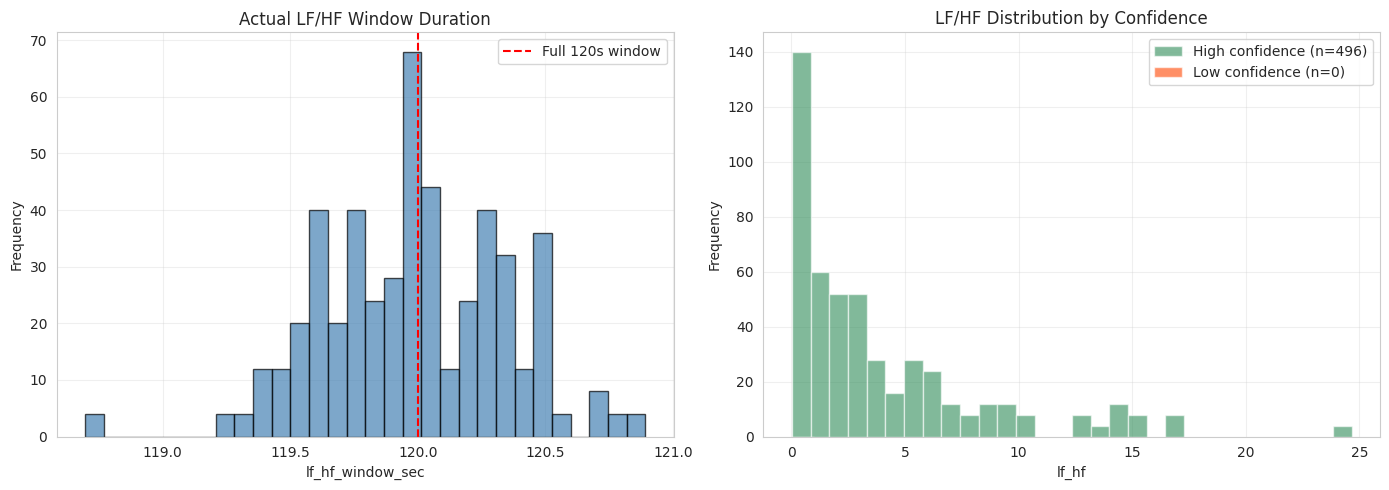

High-confidence LF/HF: mean=4.03, std=4.53
Low-confidence LF/HF:  mean=nan, std=nan

If these two distributions look meaningfully different, it's a sign that
low-confidence (short-window) LF/HF values may be systematically biased,
not just noisier — worth excluding them from model training rather than
just down-weighting.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# LF/HF window duration distribution
ax1 = axes[0]
ax1.hist(df['lf_hf_window_sec'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(120, color='red', linestyle='--', label='Full 120s window')
ax1.set_xlabel('lf_hf_window_sec')
ax1.set_ylabel('Frequency')
ax1.set_title('Actual LF/HF Window Duration')
ax1.legend()
ax1.grid(alpha=0.3)

# LF/HF distribution split by confidence
ax2 = axes[1]
high_conf = df[~df['lf_hf_low_confidence']]['lf_hf'].dropna()
low_conf = df[df['lf_hf_low_confidence']]['lf_hf'].dropna()
ax2.hist(high_conf, bins=30, alpha=0.6, label=f'High confidence (n={len(high_conf)})', color='seagreen')
ax2.hist(low_conf, bins=30, alpha=0.6, label=f'Low confidence (n={len(low_conf)})', color='orangered')
ax2.set_xlabel('lf_hf')
ax2.set_ylabel('Frequency')
ax2.set_title('LF/HF Distribution by Confidence')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"High-confidence LF/HF: mean={high_conf.mean():.2f}, std={high_conf.std():.2f}")
print(f"Low-confidence LF/HF:  mean={low_conf.mean():.2f}, std={low_conf.std():.2f}")
print()
print("If these two distributions look meaningfully different, it's a sign that")
print("low-confidence (short-window) LF/HF values may be systematically biased,")
print("not just noisier — worth excluding them from model training rather than")
print("just down-weighting.")


## 5. Feature Distributions

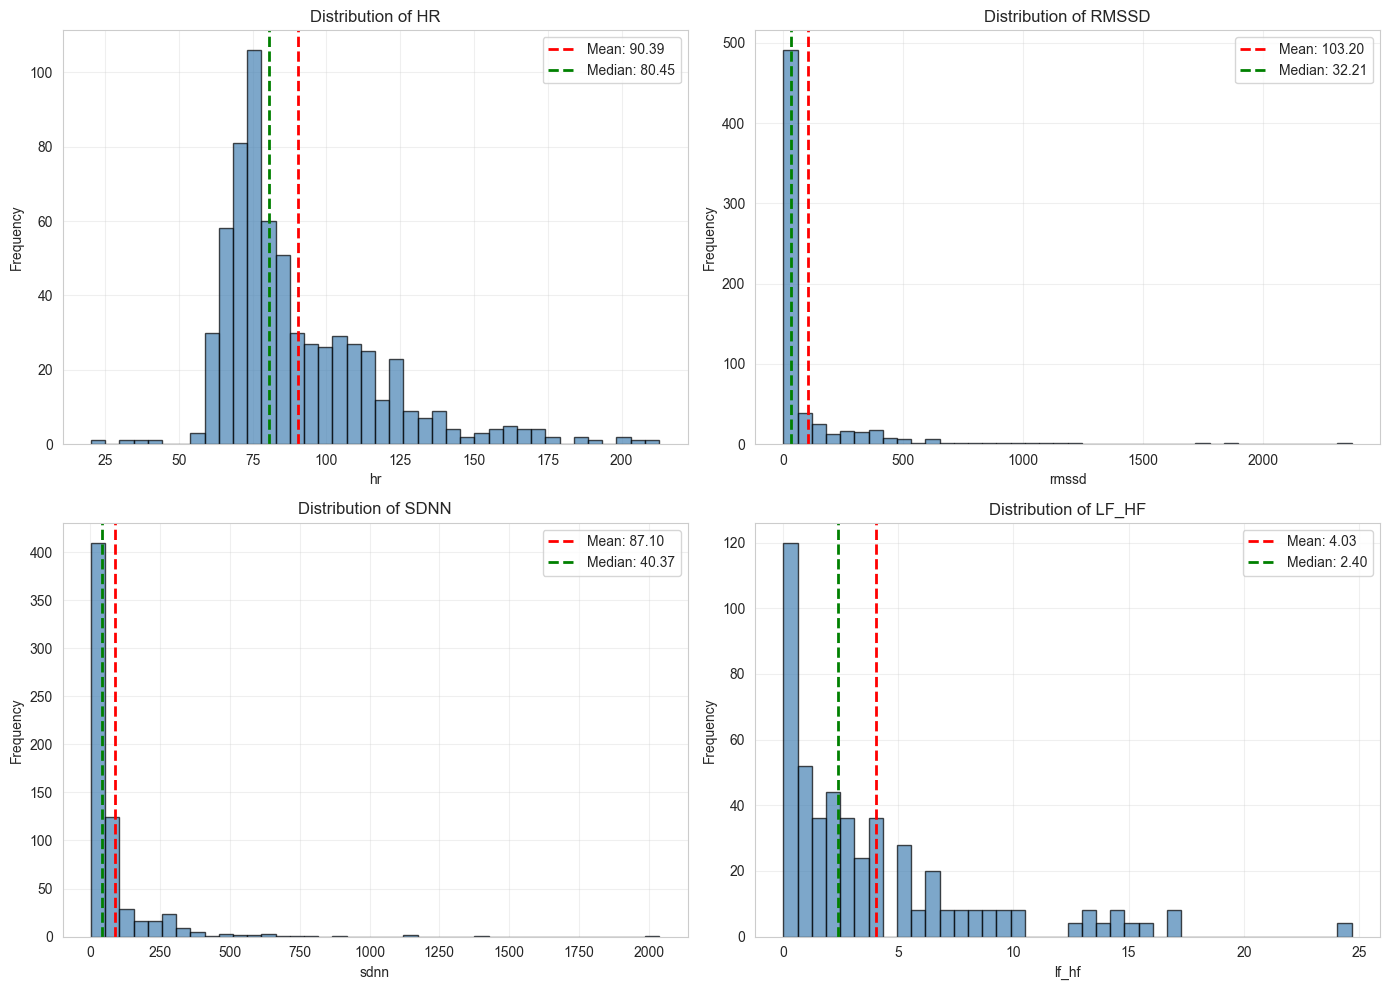

Distribution Skewness & Kurtosis:
  hr    : Skewness=  1.482, Kurtosis=  2.680
  rmssd : Skewness=  5.136, Kurtosis= 35.643
  sdnn  : Skewness=  5.914, Kurtosis= 51.250
  lf_hf : Skewness=  1.819, Kurtosis=  3.497


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax = axes[idx]
    ax.hist(df[feature].dropna(), bins=40, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(df[feature].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[feature].mean():.2f}')
    ax.axvline(df[feature].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df[feature].median():.2f}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of {feature.upper()}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Skewness and kurtosis
print("Distribution Skewness & Kurtosis:")
for feature in features:
    skew = stats.skew(df[feature].dropna())
    kurt = stats.kurtosis(df[feature].dropna())
    print(f"  {feature:6s}: Skewness={skew:7.3f}, Kurtosis={kurt:7.3f}")

## 6. Label Distribution (Physical Fatigue Score)

Label (Fatigue Score) Statistics:
  Label type: ['fatigue_rating']
  Valid (non-NaN) labels: 652 / 652 (100.0%)

count    652.000
mean      24.095
std       18.805
min        0.000
25%        9.028
50%       22.361
75%       37.639
max       77.222
Name: label, dtype: float64


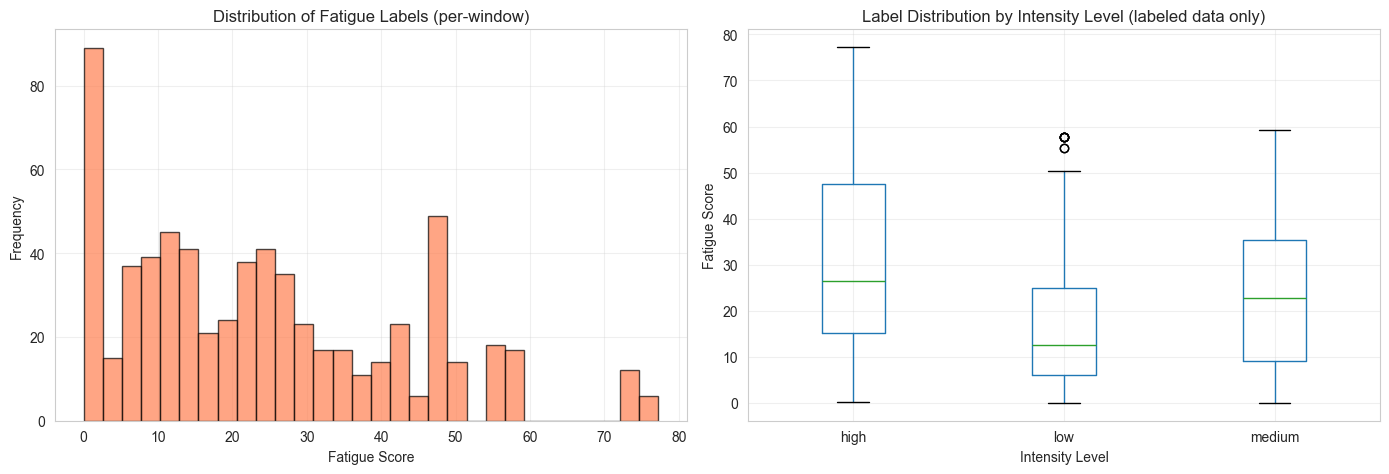


Labeled Samples Per Subject (out of total rows):
subject_id
P01    45
P02    54
P03    53
P04    57
P05    54
P06    58
P07    57
P08    48
P09    57
P10    53
P11    64
P12    52
dtype: int64

Total labeled samples: 652
Total unlabeled samples: 0


In [10]:
# NOTE: 'label' here is physicalFatigueScore from exp_fatigue.csv only.
# mentalFatigueScore is NOT currently included as a separate label column.

# Label statistics (fatigue scores)
print("Label (Fatigue Score) Statistics:")
print(f"  Label type: {df['label_type'].unique()}")
print(f"  Valid (non-NaN) labels: {df['label'].notna().sum()} / {len(df)} ({df['label'].notna().sum()/len(df)*100:.1f}%)")
print()
print(df['label'].describe().round(3))

# Distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
df['label'].hist(bins=30, ax=ax1, edgecolor='black', color='coral', alpha=0.7)
ax1.set_xlabel('Fatigue Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Fatigue Labels (per-window)')
ax1.grid(alpha=0.3)

# Boxplot by intensity level (for labeled data only)
ax2 = axes[1]
labeled_data = df[df['label'].notna()]
if len(labeled_data) > 0:
    labeled_data.boxplot(column='label', by='intensity_level', ax=ax2)
    ax2.set_xlabel('Intensity Level')
    ax2.set_ylabel('Fatigue Score')
    ax2.set_title('Label Distribution by Intensity Level (labeled data only)')
    ax2.grid(alpha=0.3)
    plt.suptitle('')  # Remove automatic title

plt.tight_layout()
plt.show()

# Label distribution by subject
print("\n" + "="*60)
print("Labeled Samples Per Subject (out of total rows):")
label_counts = df[df['label'].notna()].groupby('subject_id').size()
print(label_counts)
print(f"\nTotal labeled samples: {df['label'].notna().sum()}")
print(f"Total unlabeled samples: {df['label'].isna().sum()}")

## 7. Data Balance & Covariates

Subject Distribution:
subject_id
P01    45
P02    54
P03    53
P04    57
P05    54
P06    58
P07    57
P08    48
P09    57
P10    53
P11    64
P12    52
Name: count, dtype: int64
  Mean rows/subject: 54.3
  Std dev: 4.9

Session Distribution:
session_id
1    218
2    219
3    215
Name: count, dtype: int64

Intensity Level Distribution:
intensity_level
high      230
medium    227
low       195
Name: count, dtype: int64

Secondary Covariates:

Pre-task SSS (Sleepiness Scale, 1-7):
count    652.000000
mean       1.812883
std        0.779117
min        1.000000
25%        1.000000
50%        2.000000
75%        2.000000
max        4.000000
Name: sss_pretask, dtype: float64

Pre-task GVAS Sleepy (0-6):
count    652.000000
mean       2.088957
std        1.755763
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: gvas_sleepy, dtype: float64


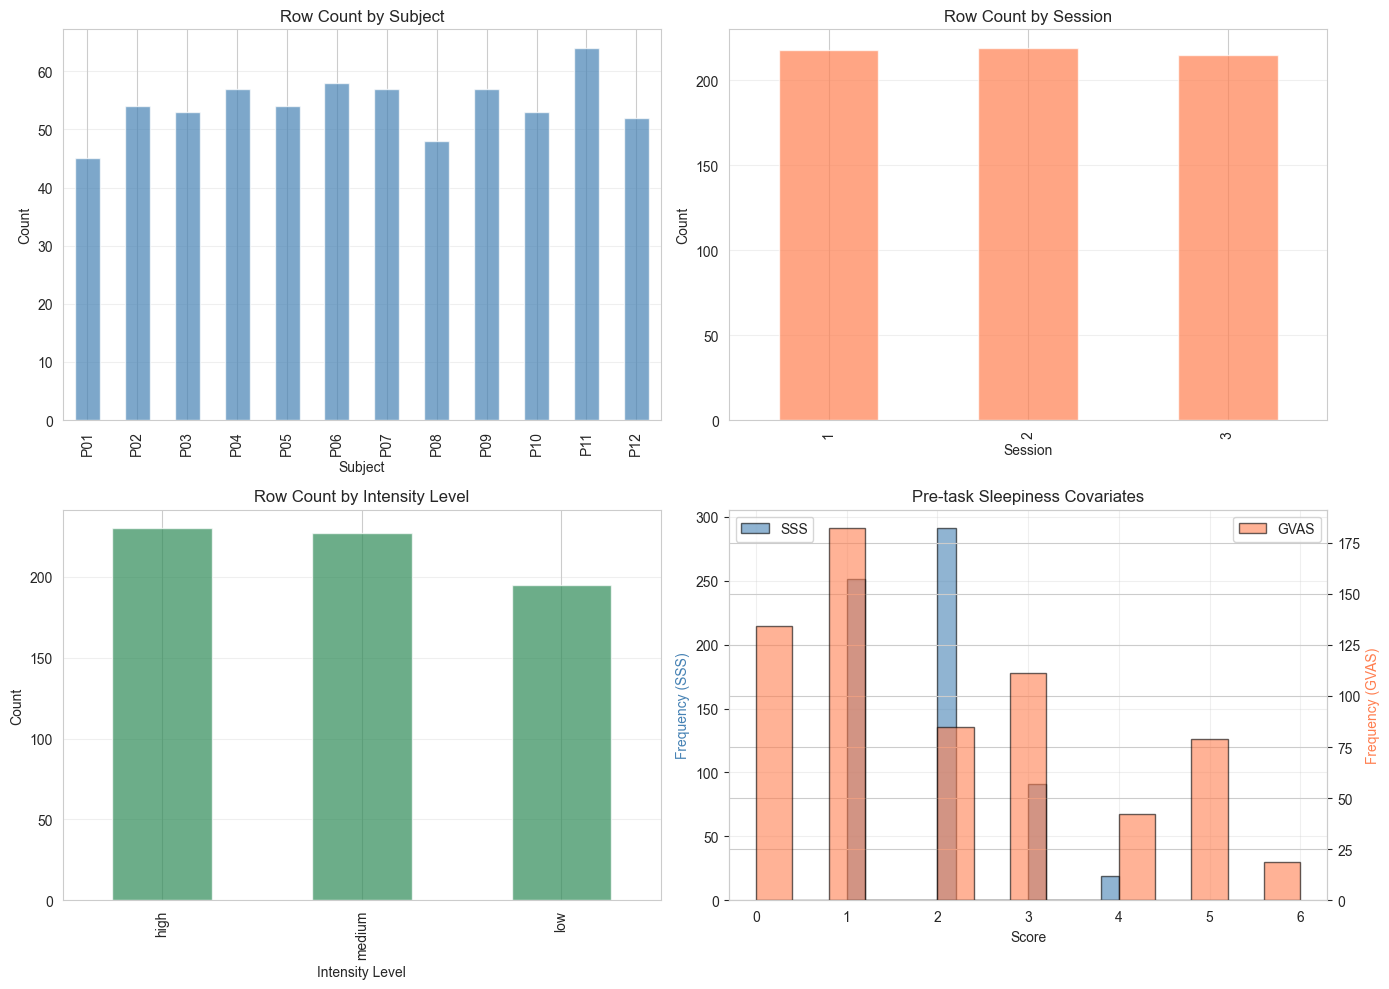

In [11]:
# Balance by subject
print("Subject Distribution:")
subject_counts = df['subject_id'].value_counts().sort_index()
print(subject_counts)
print(f"  Mean rows/subject: {subject_counts.mean():.1f}")
print(f"  Std dev: {subject_counts.std():.1f}")

# Balance by session
print("\n" + "="*60)
print("Session Distribution:")
session_counts = df['session_id'].value_counts().sort_index()
print(session_counts)

# Balance by intensity level
print("\n" + "="*60)
print("Intensity Level Distribution:")
intensity_counts = df['intensity_level'].value_counts()
print(intensity_counts)

# Covariate statistics
print("\n" + "="*60)
print("Secondary Covariates:")
print("\nPre-task SSS (Sleepiness Scale, 1-7):")
print(df['sss_pretask'].describe())
print("\nPre-task GVAS Sleepy (0-6):")
print(df['gvas_sleepy'].describe())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Subject balance
ax1 = axes[0, 0]
subject_counts.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.7)
ax1.set_xlabel('Subject')
ax1.set_ylabel('Count')
ax1.set_title('Row Count by Subject')
ax1.grid(alpha=0.3, axis='y')

# Session balance
ax2 = axes[0, 1]
session_counts.plot(kind='bar', ax=ax2, color='coral', alpha=0.7)
ax2.set_xlabel('Session')
ax2.set_ylabel('Count')
ax2.set_title('Row Count by Session')
ax2.grid(alpha=0.3, axis='y')

# Intensity level balance
ax3 = axes[1, 0]
intensity_counts.plot(kind='bar', ax=ax3, color='seagreen', alpha=0.7)
ax3.set_xlabel('Intensity Level')
ax3.set_ylabel('Count')
ax3.set_title('Row Count by Intensity Level')
ax3.grid(alpha=0.3, axis='y')

# Covariate comparison
ax4 = axes[1, 1]
ax4.hist(df['sss_pretask'], bins=15, alpha=0.6, label='SSS', color='steelblue', edgecolor='black')
ax4_twin = ax4.twinx()
ax4_twin.hist(df['gvas_sleepy'], bins=15, alpha=0.6, label='GVAS', color='coral', edgecolor='black')
ax4.set_xlabel('Score')
ax4.set_ylabel('Frequency (SSS)', color='steelblue')
ax4_twin.set_ylabel('Frequency (GVAS)', color='coral')
ax4.set_title('Pre-task Sleepiness Covariates')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Feature Correlations

Correlation Matrix (Pearson):
                hr  rmssd   sdnn  lf_hf  sss_pretask  gvas_sleepy  label
hr           1.000  0.021 -0.027 -0.018       -0.041        0.082  0.430
rmssd        0.021  1.000  0.975 -0.283        0.049        0.010  0.109
sdnn        -0.027  0.975  1.000 -0.258        0.054       -0.002  0.081
lf_hf       -0.018 -0.283 -0.258  1.000       -0.188       -0.179 -0.188
sss_pretask -0.041  0.049  0.054 -0.188        1.000        0.620  0.327
gvas_sleepy  0.082  0.010 -0.002 -0.179        0.620        1.000  0.361
label        0.430  0.109  0.081 -0.188        0.327        0.361  1.000


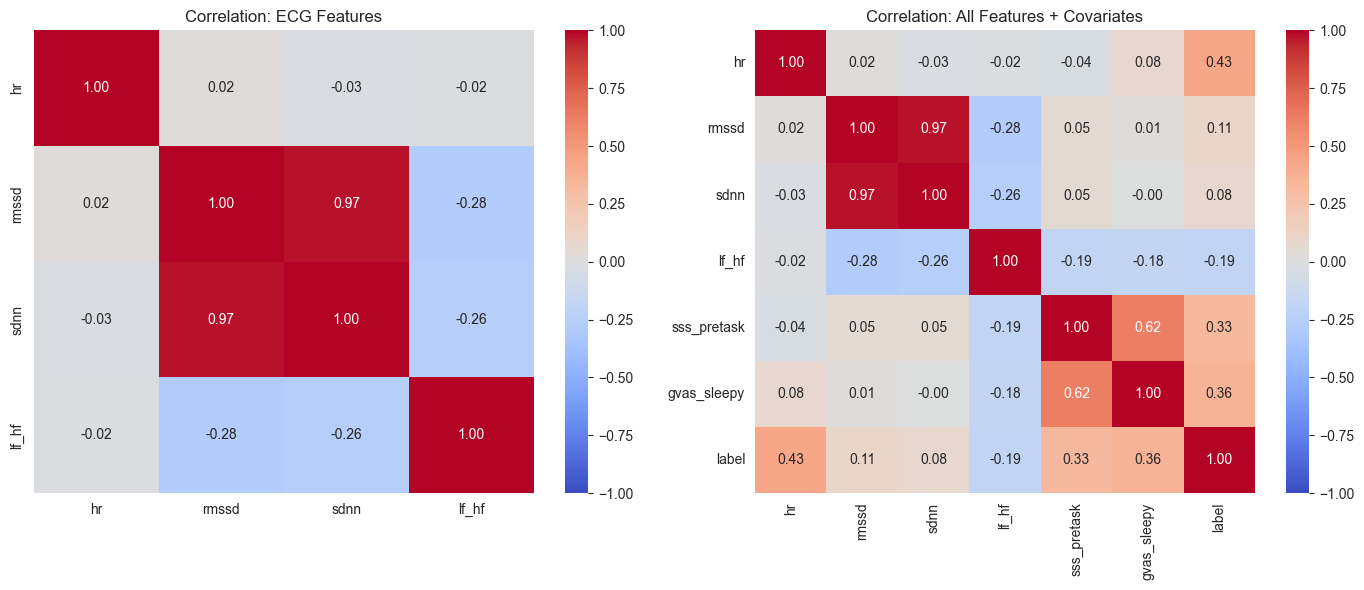


Correlations with Fatigue Label (labeled samples only):
  hr          :   0.430
  rmssd       :   0.109
  sdnn        :   0.081
  lf_hf       :  -0.188
  sss_pretask :   0.327
  gvas_sleepy :   0.361


In [12]:
# Correlation between ECG features
corr_features = ['hr', 'rmssd', 'sdnn', 'lf_hf', 'sss_pretask', 'gvas_sleepy', 'label']
corr_matrix = df[corr_features].corr()

print("Correlation Matrix (Pearson):")
print(corr_matrix.round(3))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ECG features only
ax1 = axes[0]
corr_ecg = df[['hr', 'rmssd', 'sdnn', 'lf_hf']].corr()
sns.heatmap(corr_ecg, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax1, vmin=-1, vmax=1)
ax1.set_title('Correlation: ECG Features')

# All features (with labels where available)
ax2 = axes[1]
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax2, vmin=-1, vmax=1)
ax2.set_title('Correlation: All Features + Covariates')

plt.tight_layout()
plt.show()

# Key correlations with label (for labeled samples)
print("\n" + "="*60)
print("Correlations with Fatigue Label (labeled samples only):")
labeled_df = df[df['label'].notna()]
if len(labeled_df) > 1:
    for feature in features + ['sss_pretask', 'gvas_sleepy']:
        if feature in labeled_df.columns:
            corr = labeled_df[[feature, 'label']].corr().iloc[0, 1]
            print(f"  {feature:12s}: {corr:7.3f}")

## 9. Summary & Recommendations

In [13]:
print(f"""
========================================================================
                    FatigueSet EDA Summary
========================================================================

DATASET OVERVIEW:
  - Total rows: {len(df)} (12 subjects x up to 3 sessions)
  - Columns: {len(df.columns)}
  - Windowing: 30s, BLOCK-RESTRICTED (baseline/activity/fatigue blocks only)
    -> see Section 3c: this covers roughly {rows_per_session.mean()/47*100:.0f}% of a
       session's total recorded time, not the full session.
  - Labels: block-level matching (exp_fatigue.csv paired to blocks by rank order,
    not by comparing timestamps against block ranges directly)

SUBJECT/SESSION COMPLETENESS:
  - {"All 36 subject x session combinations present" if not missing_combos else f"{len(missing_combos)} combination(s) MISSING -- see Section 3b"}

ECG/HRV FEATURES:
  - HR:    {df['hr'].min():.0f}-{df['hr'].max():.0f} bpm
  - RMSSD: {df['rmssd'].min():.1f}-{df['rmssd'].max():.0f} ms
  - SDNN:  {df['sdnn'].min():.1f}-{df['sdnn'].max():.0f} ms
  - LF/HF: {df['lf_hf'].min():.1f}-{df['lf_hf'].max():.1f}
    -> computed on a separate 2-min window; {df['lf_hf_low_confidence'].mean()*100:.0f}% of
       rows are flagged low-confidence (short trailing chunk at a block edge)

LABELS (Physical Fatigue Score only -- mentalFatigueScore not yet a separate column):
  - Coverage: {df['label'].notna().sum()}/{len(df)} ({df['label'].notna().sum()/len(df)*100:.0f}%)
  - Range: {df['label'].min():.2f}-{df['label'].max():.2f} (mean={df['label'].mean():.2f})
  - Source: exp_fatigue.csv physicalFatigueScore, block-level pairing
  - Caveat: 100% coverage is a side effect of only windowing inside the three
    blocks (which always get a paired measurement) -- not evidence that fatigue
    was measured continuously throughout the session.

COVARIATES:
  - Pre-task SSS (1-7), GVAS (0-6), Intensity (low/med/high) -- present on every row

OPEN ITEMS TO RESOLVE:
  1. {"No missing subject/session combos" if not missing_combos else "Investigate missing combo(s) in Section 3b -- raw file issue or genuine gap?"}
  2. Decide whether to switch to continuous (whole-session) windowing --
     would roughly double usable rows per the Section 3c estimate.
  3. Decide whether to add mentalFatigueScore as its own label column
     alongside the current physical-only label.
  4. Decide how to handle the {df['lf_hf_low_confidence'].mean()*100:.0f}% of LF/HF values
     flagged low-confidence -- exclude from training, or keep with the flag as
     a model input.
""")



                    FatigueSet EDA Summary

DATASET OVERVIEW:
  - Total rows: 652 (12 subjects x up to 3 sessions)
  - Columns: 17
  - Windowing: 30s, BLOCK-RESTRICTED (baseline/activity/fatigue blocks only)
    -> see Section 3c: this covers roughly 40% of a
       session's total recorded time, not the full session.
  - Labels: block-level matching (exp_fatigue.csv paired to blocks by rank order,
    not by comparing timestamps against block ranges directly)

SUBJECT/SESSION COMPLETENESS:
  - 1 combination(s) MISSING -- see Section 3b

ECG/HRV FEATURES:
  - HR:    20-213 bpm
  - RMSSD: 1.8-2367 ms
  - SDNN:  1.9-2037 ms
  - LF/HF: 0.0-24.7
    -> computed on a separate 2-min window; 24% of
       rows are flagged low-confidence (short trailing chunk at a block edge)

LABELS (Physical Fatigue Score only -- mentalFatigueScore not yet a separate column):
  - Coverage: 652/652 (100%)
  - Range: 0.00-77.22 (mean=24.09)
  - Source: exp_fatigue.csv physicalFatigueScore, block-level pairing